In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
sns.set_style("darkgrid")

In [82]:
train = pd.read_csv("https://raw.githubusercontent.com/manasjadhav0086/retail-demand-forecasting/refs/heads/main/train.csv")
features = pd.read_csv("https://raw.githubusercontent.com/manasjadhav0086/retail-demand-forecasting/refs/heads/main/features.csv")
stores = pd.read_csv("https://raw.githubusercontent.com/manasjadhav0086/retail-demand-forecasting/refs/heads/main/stores.csv")

print(train.head())
print(features.head())
print(stores.head())

   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False
   Store        Date  Temperature  Fuel_Price         CPI  Unemployment  \
0      1  05-02-2010        42.31       2.572  211.096358         8.106   
1      1  12-02-2010        38.51       2.548  211.242170         8.106   
2      1  19-02-2010        39.93       2.514  211.289143         8.106   
3      1  26-02-2010        46.63       2.561  211.319643         8.106   
4      1  05-03-2010        46.50       2.625  211.350143         8.106   

   IsHoliday  
0      False  
1       True  
2      False  
3      False  
4      False  
   Store Type    Size
0      1    A  151315
1      2    A  202307
2      3    B   37392
3      4    A  205863
4      5    B   34875


In [83]:
print(train.shape)
print(train.info())
print(train.isnull().sum())

(421570, 5)
<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), str(1)
memory usage: 17.3 MB
None
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64


In [84]:
train['Date'] = pd.to_datetime(train['Date'])
features['Date'] = pd.to_datetime(features['Date'], dayfirst=True)
df = train.merge(features, on=['Store','Date'], how='left')
df = df.merge(stores, on='Store', how='left')

print(df.head())

   Store  Dept       Date  Weekly_Sales  IsHoliday_x  Temperature  Fuel_Price  \
0      1     1 2010-02-05      24924.50        False        42.31       2.572   
1      1     1 2010-02-12      46039.49         True        38.51       2.548   
2      1     1 2010-02-19      41595.55        False        39.93       2.514   
3      1     1 2010-02-26      19403.54        False        46.63       2.561   
4      1     1 2010-03-05      21827.90        False        46.50       2.625   

          CPI  Unemployment  IsHoliday_y Type    Size  
0  211.096358         8.106        False    A  151315  
1  211.242170         8.106         True    A  151315  
2  211.289143         8.106        False    A  151315  
3  211.319643         8.106        False    A  151315  
4  211.350143         8.106        False    A  151315  


In [85]:
df['Date'] = pd.to_datetime(df['Date'])

df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.isocalendar().week

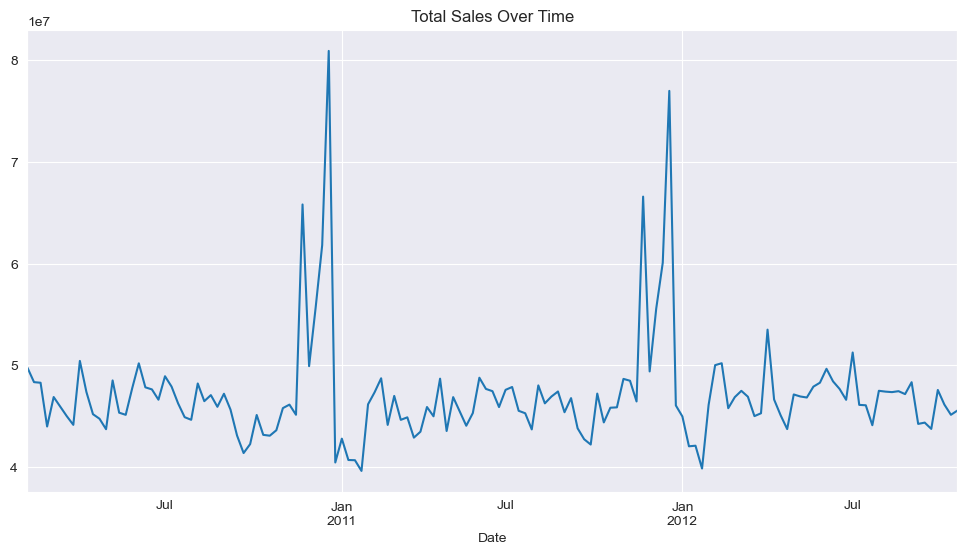

In [86]:
sales_trend = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(12,6))
sales_trend.plot()
plt.title("Total Sales Over Time")
plt.show()

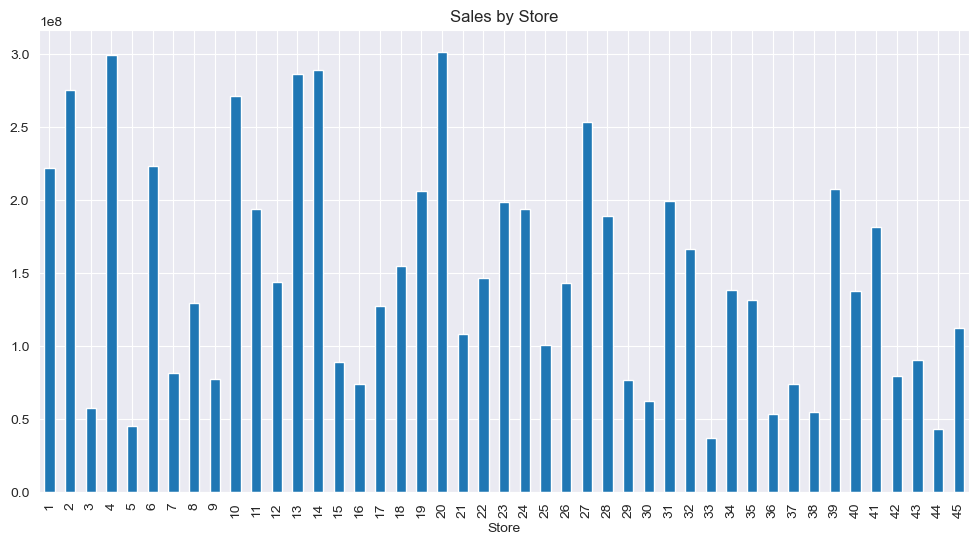

In [87]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum()

plt.figure(figsize=(12,6))
store_sales.plot(kind='bar')
plt.title("Sales by Store")
plt.show()

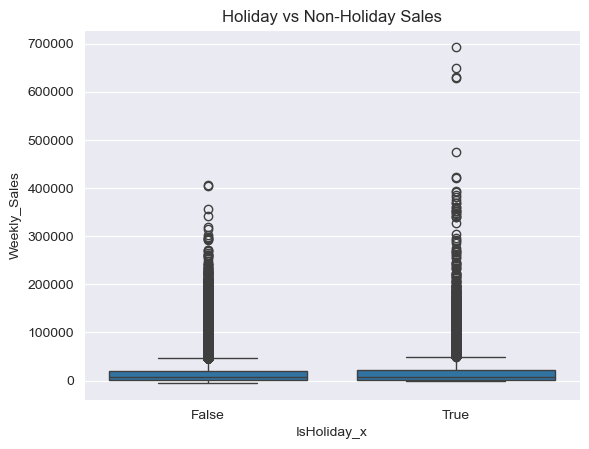

In [88]:
sns.boxplot(x='IsHoliday_x', y='Weekly_Sales', data=df)

plt.title("Holiday vs Non-Holiday Sales")
plt.show()

In [89]:
df = df.sort_values("Date")

df['lag_1'] = df['Weekly_Sales'].shift(1)
df['lag_2'] = df['Weekly_Sales'].shift(2)

df['rolling_mean'] = df['Weekly_Sales'].rolling(4).mean()

df = df.dropna()


In [90]:
features = [
'Store',
'Dept',
'month',
'week',
'Temperature',
'Fuel_Price',
'CPI',
'Unemployment',
'lag_1',
'lag_2',
'rolling_mean'
]

X = df[features]

y = df['Weekly_Sales']

In [91]:
train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [92]:
model = XGBRegressor()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [93]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("RMSE:", rmse)

RMSE: 6331.518069889733


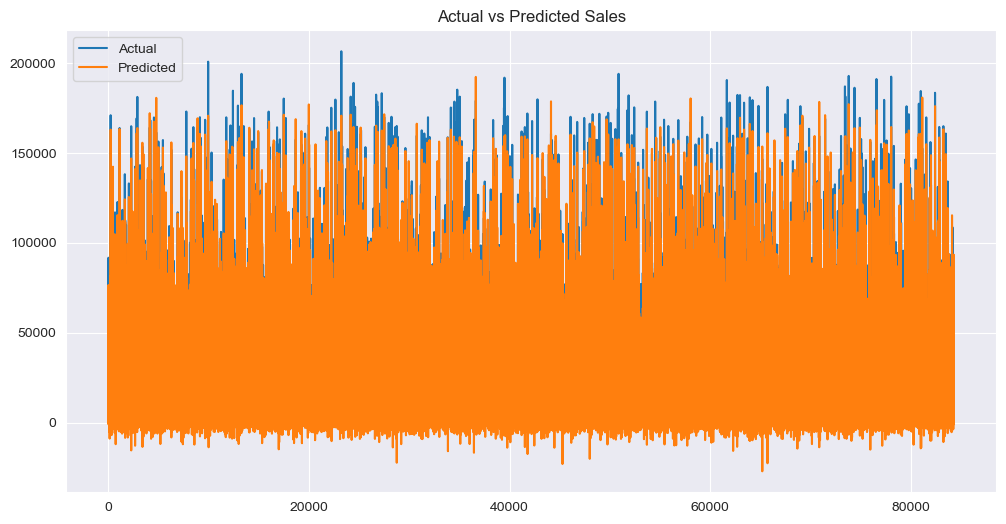

In [94]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")

plt.legend()

plt.title("Actual vs Predicted Sales")

plt.show()

In [95]:
results = pd.DataFrame({
"Actual": y_test,
"Predicted": predictions
})

results.to_csv("predictions.csv", index=False)